In [ ]:
!pip install -q kagglehub torch_geometric

In [ ]:
import kagglehub, os

path = kagglehub.dataset_download("manh123df/deap-dataset")
print("Path to dataset files:", path)

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:10]:
        print(f"{indent}  {f}")
    if len(files) > 10:
        print(f"{indent}  ... ({len(files)} files total)")


Using Colab cache for faster access to the 'deap-dataset' dataset.
Path to dataset files: /kaggle/input/deap-dataset
deap-dataset/
  deap-dataset/
    EDA_DEAP.ipynb
    data_preprocessed_python/
      s20.dat
      s17.dat
      s31.dat
      s14.dat
      s32.dat
      s28.dat
      s24.dat
      s18.dat
      s22.dat
      s02.dat
      ... (32 files total)
    Metadata/
      video_list_fixed.xlsx
      online_ratings.xls
      participant_questionnaire.xls
      video_list.xlsx
      participant_ratings.xls
    audio_stimuli_MIDI/
      exp_id_18.mid
      exp_id_27.mid
      exp_id_28.mid
      exp_id_30.mid
      exp_id_15.mid
      exp_id_40.mid
      exp_id_2.mid
      exp_id_3.mid
      exp_id_24.mid
      exp_id_14.mid
      ... (40 files total)
    metadata_xls/
      online_ratings.xls
      participant_questionnaire.xls
      participant_ratings.xls
      video_list.xls
    audio_stimuli_MIDI_tempo24/
      exp_id_26_tempo24.mid
      exp_id_39_tempo24.mid
      exp_id_6_

In [ ]:
import pickle
import numpy as np
import glob

EEG_CHANNELS = 32
FS = 128
BASELINE_SEC = 3
def load_subject(filepath):
    with open(filepath, "rb") as f:
        d = pickle.load(f, encoding="latin1")
    data = d["data"]
    labels = d["labels"]
    return data, labels

subject_files = sorted(glob.glob(os.path.join(path, "**", "s*.dat"), recursive=True))
print(f"Found {len(subject_files)} subject files")
assert len(subject_files) > 0, "No .dat files found — inspect Cell 2's output and fix the glob pattern / loader."

data0, labels0 = load_subject(subject_files[0])
print("data shape:", data0.shape, "labels shape:", labels0.shape)


Found 32 subject files
data shape: (40, 40, 8064) labels shape: (40, 4)


In [ ]:
import pickle as _pkl
data0, labels0 = load_subject(subject_files[0]) if False else (None, None)  # placeholder, real load below
import pickle as _pkl
with open(subject_files[0], "rb") as f:
    d0 = _pkl.load(f, encoding="latin1")

print("Keys:", list(d0.keys()))
print("data shape (trials, channels, samples):", d0["data"].shape)
print("labels shape (trials, [valence, arousal, dominance, liking]):", d0["labels"].shape)
print("dtype:", d0["data"].dtype)
print("any NaNs in data:", np.isnan(d0["data"]).any())
print("any NaNs in labels:", np.isnan(d0["labels"]).any())
print("labels range: min", d0["labels"].min(axis=0), "max", d0["labels"].max(axis=0))


Keys: ['labels', 'data']
data shape (trials, channels, samples): (40, 40, 8064)
labels shape (trials, [valence, arousal, dominance, liking]): (40, 4)
dtype: float64
any NaNs in data: False
any NaNs in labels: False
labels range: min [0.   1.   2.04 3.87] max [8.27 8.15 9.   8.47]


In [ ]:
subject_trial_counts = []
for fp in subject_files:
    with open(fp, "rb") as f:
        dd = _pkl.load(f, encoding="latin1")
    subject_trial_counts.append(dd["data"].shape[0])

print(f"Subjects found: {len(subject_files)}")
print(f"Trials per subject: {set(subject_trial_counts)}  (expect all subjects to match, e.g. {{40}})")


Subjects found: 32
Trials per subject: {40}  (expect all subjects to match, e.g. {40})


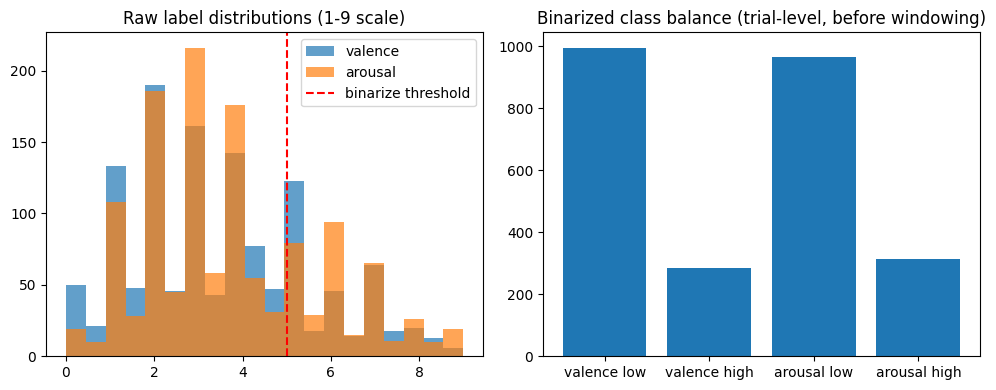

Valence: [995 285] (low/high)  |  Arousal: [965 315] (low/high)


In [ ]:
import matplotlib.pyplot as plt

all_raw_labels = []
for fp in subject_files:
    with open(fp, "rb") as f:
        dd = _pkl.load(f, encoding="latin1")
    all_raw_labels.append(dd["labels"])
all_raw_labels = np.concatenate(all_raw_labels, axis=0)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(all_raw_labels[:, 0], bins=20, alpha=0.7, label="valence")
axes[0].hist(all_raw_labels[:, 1], bins=20, alpha=0.7, label="arousal")
axes[0].axvline(5, color="red", linestyle="--", label="binarize threshold")
axes[0].set_title("Raw label distributions (1-9 scale)")
axes[0].legend()

val_bin = (all_raw_labels[:, 0] >= 5).astype(int)
aro_bin = (all_raw_labels[:, 1] >= 5).astype(int)
axes[1].bar(["valence low", "valence high", "arousal low", "arousal high"],
            [np.sum(val_bin == 0), np.sum(val_bin == 1), np.sum(aro_bin == 0), np.sum(aro_bin == 1)])
axes[1].set_title("Binarized class balance (trial-level, before windowing)")
plt.tight_layout()
plt.show()

print(f"Valence: {np.bincount(val_bin)} (low/high)  |  Arousal: {np.bincount(aro_bin)} (low/high)")


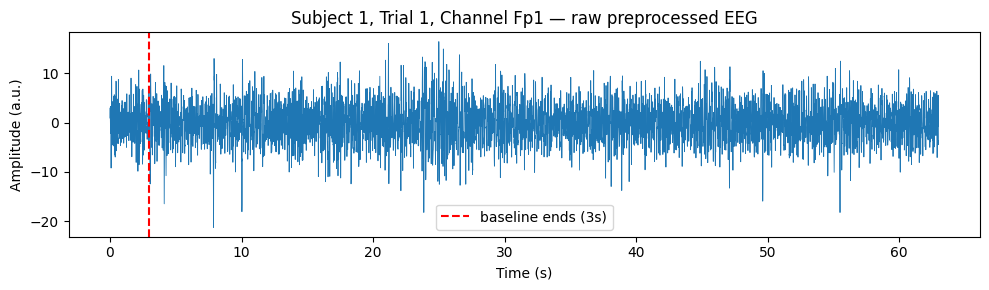

Amplitude stats -- mean: -0.028258582130643233 std: 3.8894215516563397 min: -21.300120846926255 max: 16.481104245964808


In [ ]:
with open(subject_files[0], "rb") as f:
    d0 = _pkl.load(f, encoding="latin1")

trial0_ch0 = d0["data"][0, 0, :]
t = np.arange(len(trial0_ch0)) / 128.0

plt.figure(figsize=(10, 3))
plt.plot(t, trial0_ch0, linewidth=0.6)
plt.axvline(3, color="red", linestyle="--", label="baseline ends (3s)")
plt.xlabel("Time (s)"); plt.ylabel("Amplitude (a.u.)")
plt.title("Subject 1, Trial 1, Channel Fp1 — raw preprocessed EEG")
plt.legend(); plt.tight_layout(); plt.show()

print("Amplitude stats -- mean:", trial0_ch0.mean(), "std:", trial0_ch0.std(),
      "min:", trial0_ch0.min(), "max:", trial0_ch0.max())


In [ ]:
import numpy as np
from scipy.signal import welch
from scipy.integrate import trapezoid
from multiprocessing import Pool, cpu_count
import itertools
import os

BANDS = {
    "theta": (4, 8),
    "alpha": (8, 13),
    "low_beta": (13, 20),
    "high_beta": (20, 30),
    "gamma": (30, 45),
}
WINDOW_SEC = 4
WINDOW_SAMPLES = WINDOW_SEC * FS

def bandpower(sig, fs, band):
    f, Pxx = welch(sig, fs=fs, nperseg=min(len(sig), 256))
    lo, hi = band
    idx = np.logical_and(f >= lo, f <= hi)
    return trapezoid(Pxx[idx], f[idx])

def extract_features_for_trial(trial_eeg):
    n_windows = trial_eeg.shape[1] // WINDOW_SAMPLES
    feats = []
    for w in range(n_windows):
        seg = trial_eeg[:, w*WINDOW_SAMPLES:(w+1)*WINDOW_SAMPLES]
        window_feats = np.zeros((EEG_CHANNELS, len(BANDS)))
        for ch in range(EEG_CHANNELS):
            for b_idx, band in enumerate(BANDS.values()):
                window_feats[ch, b_idx] = bandpower(seg[ch], FS, band)
        feats.append(window_feats)
    return feats

def _process_single_trial_data(args):
    eeg_data_for_trial, valence_label, arousal_label, s_idx = args
    window_feats_list = extract_features_for_trial(eeg_data_for_trial)
    results_for_trial = []
    for wf in window_feats_list:
        results_for_trial.append({
            'X': np.log1p(wf),
            'y_valence': valence_label,
            'y_arousal': arousal_label,
            'subject_idx': s_idx
        })
    return results_for_trial

CACHED_FEATURES_FILE = "deap_eeg_features.npz"

MAX_SUBJECTS = 19

if os.path.exists(CACHED_FEATURES_FILE):
    print(f"Loading features from cached file: {CACHED_FEATURES_FILE}")
    cached_data = np.load(CACHED_FEATURES_FILE)
    all_X = cached_data['all_X']
    all_y_valence = cached_data['all_y_valence']
    all_y_arousal = cached_data['all_y_arousal']
    all_subjects = cached_data['all_subjects']
else:
    print(f"Cached file not found. Extracting features and saving to {CACHED_FEATURES_FILE}")
    all_X_parallel, all_y_valence_parallel, all_y_arousal_parallel, all_subjects_parallel = [], [], [], []

    num_processes = cpu_count()
    print(f"Using {num_processes} processes for feature extraction.")

    with Pool(processes=num_processes) as pool:
        tasks = []
        for s_idx, fpath in enumerate(subject_files[:MAX_SUBJECTS]):
            data, labels = load_subject(fpath) # load_subject from previous cell
            baseline_samples = BASELINE_SEC * FS
            for t in range(data.shape[0]):
                eeg = data[t, :EEG_CHANNELS, baseline_samples:]
                eeg = (eeg - eeg.mean(axis=1, keepdims=True)) / (eeg.std(axis=1, keepdims=True) + 1e-8)
                valence_label = int(labels[t, 0] >= 5)
                arousal_label = int(labels[t, 1] >= 5)
                tasks.append((eeg, valence_label, arousal_label, s_idx))

        all_trial_results = pool.map(_process_single_trial_data, tasks)

    for item in itertools.chain.from_iterable(all_trial_results):
        all_X_parallel.append(item['X'])
        all_y_valence_parallel.append(item['y_valence'])
        all_y_arousal_parallel.append(item['y_arousal'])
        all_subjects_parallel.append(item['subject_idx'])

    all_X = np.stack(all_X_parallel)
    all_y_valence = np.array(all_y_valence_parallel)
    all_y_arousal = np.array(all_y_arousal_parallel)
    all_subjects = np.array(all_subjects_parallel)

    np.savez_compressed(
        CACHED_FEATURES_FILE,
        all_X=all_X,
        all_y_valence=all_y_valence,
        all_y_arousal=all_y_arousal,
        all_subjects=all_subjects
    )

print("Feature tensor:", all_X.shape)
print("Valence balance:", np.bincount(all_y_valence))
print("Arousal balance:", np.bincount(all_y_arousal))
print("Subjects:", len(np.unique(all_subjects)))

Loading features from cached file: deap_eeg_features.npz
Feature tensor: (11400, 32, 5)
Valence balance: [8850 2550]
Arousal balance: [8625 2775]
Subjects: 19


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

y = all_y_valence

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(all_X, y, groups=all_subjects))

print(f"Train windows: {len(train_idx)} from {len(set(all_subjects[train_idx]))} subjects")
print(f"Test windows:  {len(test_idx)} from {len(set(all_subjects[test_idx]))} subjects")
assert set(all_subjects[train_idx]).isdisjoint(set(all_subjects[test_idx])), "Subject leakage between train/test!"

X_train_raw, X_test_raw = all_X[train_idx], all_X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

mean = X_train_raw.mean(axis=(0, 1), keepdims=True)
std = X_train_raw.std(axis=(0, 1), keepdims=True) + 1e-8
X_train = (X_train_raw - mean) / std
X_test = (X_test_raw - mean) / std


Train windows: 9000 from 15 subjects
Test windows:  2400 from 4 subjects


In [ ]:
CHANNEL_NAMES = ["Fp1","AF3","F3","F7","FC5","FC1","C3","T7","CP5","CP1","P3","P7","PO3","O1","Oz","Pz",
                  "Fp2","AF4","Fz","F4","F8","FC6","FC2","Cz","C4","T8","CP6","CP2","P4","P8","PO4","O2"]

POS_2D = {
    "Fp1": (-0.3, 0.95), "Fp2": (0.3, 0.95), "AF3": (-0.25, 0.75), "AF4": (0.25, 0.75),
    "F7": (-0.85, 0.55), "F3": (-0.45, 0.55), "Fz": (0.0, 0.55), "F4": (0.45, 0.55), "F8": (0.85, 0.55),
    "FC5": (-0.65, 0.3), "FC1": (-0.2, 0.3), "FC2": (0.2, 0.3), "FC6": (0.65, 0.3),
    "T7": (-1.0, 0.0), "C3": (-0.45, 0.0), "Cz": (0.0, 0.0), "C4": (0.45, 0.0), "T8": (1.0, 0.0),
    "CP5": (-0.65, -0.3), "CP1": (-0.2, -0.3), "CP2": (0.2, -0.3), "CP6": (0.65, -0.3),
    "P7": (-0.85, -0.55), "P3": (-0.45, -0.55), "Pz": (0.0, -0.55), "P4": (0.45, -0.55), "P8": (0.85, -0.55),
    "PO3": (-0.25, -0.75), "PO4": (0.25, -0.75), "O1": (-0.3, -0.95), "Oz": (0.0, -0.95), "O2": (0.3, -0.95),
}

coords = np.array([POS_2D[ch] for ch in CHANNEL_NAMES])
n_nodes = len(CHANNEL_NAMES)

from scipy.spatial.distance import cdist
dist = cdist(coords, coords)
sigma = dist[dist > 0].std()
weight = np.exp(-(dist ** 2) / (2 * sigma ** 2))
np.fill_diagonal(weight, 0)

K = 5
edge_index_list, edge_weight_list = [], []
for i in range(n_nodes):
    neighbors = np.argsort(-weight[i])[:K]
    for j in neighbors:
        edge_index_list.append([i, j])
        edge_weight_list.append(weight[i, j])

edge_index = np.array(edge_index_list).T
edge_weight = np.array(edge_weight_list)
print("Graph: {} nodes, {} directed edges (k={} nearest neighbors)".format(n_nodes, edge_index.shape[1], K))


Graph: 32 nodes, 160 directed edges (k=5 nearest neighbors)


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

all_X = np.concatenate([X_train, X_test], axis=0)
y = all_y_valence

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(all_X, y, groups=all_subjects))
assert set(all_subjects[train_idx]).isdisjoint(set(all_subjects[test_idx]))

mean = all_X[train_idx].mean(axis=(0, 1), keepdims=True)
std = all_X[train_idx].std(axis=(0, 1), keepdims=True) + 1e-8
X_train = (all_X[train_idx] - mean) / std
X_test = (all_X[test_idx] - mean) / std
y_train, y_test = y[train_idx], y[test_idx]
print(f"Train: {len(train_idx)} windows / {len(set(all_subjects[train_idx]))} subjects | "
      f"Test: {len(test_idx)} windows / {len(set(all_subjects[test_idx]))} subjects")

Train: 9000 windows / 15 subjects | Test: 2400 windows / 4 subjects


In [ ]:
import torch
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
edge_index_t = torch.tensor(edge_index, dtype=torch.long)
edge_weight_t = torch.tensor(edge_weight, dtype=torch.float)

class EEGGraphDataset(Dataset):
    def __init__(self, X, y):
        super().__init__()
        self.X = torch.tensor(X, dtype=torch.float)
        self.y = torch.tensor(y, dtype=torch.long)
    def len(self): return len(self.y)
    def get(self, idx):
        return Data(x=self.X[idx], edge_index=edge_index_t, edge_weight=edge_weight_t, y=self.y[idx])

train_loader = DataLoader(EEGGraphDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(EEGGraphDataset(X_test, y_test), batch_size=64, shuffle=False)


In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing, global_mean_pool

class GNNLayer(MessagePassing):
    def __init__(self, in_dim, out_dim):
        super().__init__(aggr="mean")
        self.lin_neigh = nn.Linear(in_dim, out_dim)
        self.lin_self = nn.Linear(in_dim, out_dim)

    def forward(self, x, edge_index, edge_weight):
        return self.propagate(edge_index, x=x, edge_weight=edge_weight) + self.lin_self(x)

    def message(self, x_j, edge_weight):
        return self.lin_neigh(x_j) * edge_weight.view(-1, 1)

class GNN(nn.Module):
    def __init__(self, in_dim=5, hidden=32, num_classes=2, dropout=0.3):
        super().__init__()
        self.gnn1 = GNNLayer(in_dim, hidden)
        self.gnn2 = GNNLayer(hidden, hidden)
        self.dropout = dropout
        self.head = nn.Linear(hidden, num_classes)

    def forward(self, x, edge_index, edge_weight, batch):
        x = F.relu(self.gnn1(x, edge_index, edge_weight))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.gnn2(x, edge_index, edge_weight))
        x = global_mean_pool(x, batch)
        return self.head(x)

model = GNN().to(device)
print(model)


GNN(
  (gnn1): GNNLayer()
  (gnn2): GNNLayer()
  (head): Linear(in_features=32, out_features=2, bias=True)
)


In [ ]:
# Train
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, n = 0, 0, 0
    for batch in loader:
        batch = batch.to(device)
        if train: optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.edge_weight, batch.batch)
        loss = criterion(out, batch.y)
        if train: loss.backward(); optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        correct += (out.argmax(dim=1) == batch.y).sum().item()
        n += batch.num_graphs
    return total_loss / n, correct / n

for epoch in range(1, 41):
    tr_loss, tr_acc = run_epoch(train_loader, True)
    if epoch % 5 == 0 or epoch == 40:
        te_loss, te_acc = run_epoch(test_loader, False)
        print(f"Epoch {epoch:3d} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | test loss {te_loss:.4f} acc {te_acc:.3f}")


Epoch   5 | train loss 0.5218 acc 0.773 | test loss 0.4966 acc 0.787
Epoch  10 | train loss 0.5166 acc 0.773 | test loss 0.4895 acc 0.787
Epoch  15 | train loss 0.5157 acc 0.773 | test loss 0.4917 acc 0.787
Epoch  20 | train loss 0.5126 acc 0.774 | test loss 0.4968 acc 0.785
Epoch  25 | train loss 0.5117 acc 0.774 | test loss 0.4967 acc 0.787
Epoch  30 | train loss 0.5098 acc 0.774 | test loss 0.4938 acc 0.787
Epoch  35 | train loss 0.5077 acc 0.773 | test loss 0.4895 acc 0.787
Epoch  40 | train loss 0.5071 acc 0.773 | test loss 0.4911 acc 0.788


In [ ]:
# Evaluate
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

model.eval()
preds, trues = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.edge_weight, batch.batch)
        preds.append(out.argmax(1).cpu()); trues.append(batch.y.cpu())
preds = torch.cat(preds).numpy(); trues = torch.cat(trues).numpy()

print(f"Accuracy: {accuracy_score(trues, preds):.3f} | Macro-F1: {f1_score(trues, preds, average='macro'):.3f}")
print(classification_report(trues, preds, target_names=["Low", "High"]))
print("Confusion matrix:\n", confusion_matrix(trues, preds))


Accuracy: 0.788 | Macro-F1: 0.443
              precision    recall  f1-score   support

         Low       0.79      1.00      0.88      1890
        High       1.00      0.00      0.00       510

    accuracy                           0.79      2400
   macro avg       0.89      0.50      0.44      2400
weighted avg       0.83      0.79      0.69      2400

Confusion matrix:
 [[1890    0]
 [ 509    1]]
